In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error

In [3]:

DATA_PATH = "https://raw.githubusercontent.com/selaluar/Arya-Pratama-Hendri_2411533008_ML2526/refs/heads/main/Praktikum4/Advertising.csv"

df = pd.read_csv(DATA_PATH)

print("Data berhasil dibaca")
print("Ukuran dataset:", df.shape)

df.head()

Data berhasil dibaca
Ukuran dataset: (200, 5)


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:

df.columns = df.columns.str.strip()


df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Nama kolom setelah dibersihkan:")
print(df.columns)

df.head()

Nama kolom setelah dibersihkan:
Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')


,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:


X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.head())

Shape X: (200, 3)
Shape y: (200,)


,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=== Holdout Method ===")
print("RMSE Train:", rmse_train)
print("RMSE Test :", rmse_test)

=== Holdout Method ===
RMSE Train: 1.644727765644337
RMSE Test : 1.78159966153345


In [8]:


gap = rmse_test - rmse_train
relative_gap = gap / rmse_train

print("=== Analisis Holdout Validation ===")
print("RMSE Train:", round(rmse_train, 4))
print("RMSE Test :", round(rmse_test, 4))
print("Selisih RMSE:", round(gap, 4))
print("Relative Gap:", f"{relative_gap:.2%}")

print("\nJawaban:")

if relative_gap > 0.20:
    print("a. RMSE train jauh lebih kecil daripada RMSE test.")
    print("b. Model cenderung overfit karena performa pada data latih jauh lebih baik daripada data test.")
elif abs(relative_gap) <= 0.20:
    print("a. RMSE train dan RMSE test relatif dekat.")
    print("b. Model tidak menunjukkan overfitting yang kuat. Model cukup mampu melakukan generalisasi.")
else:
    print("a. RMSE test lebih kecil daripada RMSE train.")
    print("b. Model tidak overfit. Hal ini bisa terjadi karena data test lebih mudah diprediksi daripada data train.")

=== Analisis Holdout Validation ===
RMSE Train: 1.6447
RMSE Test : 1.7816
Selisih RMSE: 0.1369
Relative Gap: 8.32%

Jawaban:
a. RMSE train dan RMSE test relatif dekat.
b. Model tidak menunjukkan overfitting yang kuat. Model cukup mampu melakukan generalisasi.


In [9]:

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rmse_list = []

for fold, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train_k = X.iloc[train_index]
    X_test_k = X.iloc[test_index]
    y_train_k = y.iloc[train_index]
    y_test_k = y.iloc[test_index]

    model_k = LinearRegression()
    model_k.fit(X_train_k, y_train_k)

    y_pred_k = model_k.predict(X_test_k)

    rmse_k = np.sqrt(mean_squared_error(y_test_k, y_pred_k))
    rmse_list.append(rmse_k)

    print(f"Fold {fold} - RMSE: {rmse_k:.4f}")

rmse_kfold_mean = np.mean(rmse_list)
rmse_kfold_std = np.std(rmse_list, ddof=1)

print("\n=== K-Fold Manual 5 Fold ===")
print("RMSE tiap fold :", rmse_list)
print("RMSE rata-rata :", rmse_kfold_mean)
print("Standar deviasi:", rmse_kfold_std)

Fold 1 - RMSE: 1.7816
Fold 2 - RMSE: 1.8149
Fold 3 - RMSE: 1.2739
Fold 4 - RMSE: 1.6822
Fold 5 - RMSE: 1.9761

=== K-Fold Manual 5 Fold ===
RMSE tiap fold : [np.float64(1.7815996615334508), np.float64(1.8148659575063775), np.float64(1.273879670030852), np.float64(1.682170405578691), np.float64(1.9761418310755126)]
RMSE rata-rata : 1.705731505144977
Standar deviasi: 0.26355226384916386


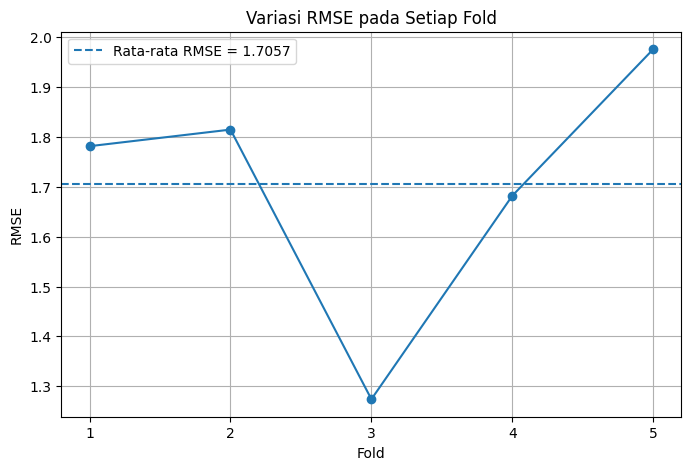

In [10]:


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rmse_list) + 1), rmse_list, marker="o")
plt.axhline(rmse_kfold_mean, linestyle="--", label=f"Rata-rata RMSE = {rmse_kfold_mean:.4f}")
plt.title("Variasi RMSE pada Setiap Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks(range(1, len(rmse_list) + 1))
plt.legend()
plt.grid(True)
plt.show()

In [11]:


cv_scores = np.sqrt(
    -cross_val_score(
        LinearRegression(),
        X,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
)

print("=== K-Fold dengan cross_val_score ===")
print("RMSE tiap fold :", cv_scores)
print("RMSE rata-rata :", cv_scores.mean())
print("Standar deviasi:", cv_scores.std(ddof=1))

=== K-Fold dengan cross_val_score ===
RMSE tiap fold : [1.78159966 1.81486596 1.27387967 1.68217041 1.97614183]
RMSE rata-rata : 1.705731505144977
Standar deviasi: 0.26355226384916386


In [12]:


comparison_df = pd.DataFrame({
    "Metode": [
        "Holdout Test",
        "K-Fold Manual Mean",
        "K-Fold cross_val_score Mean"
    ],
    "RMSE": [
        rmse_test,
        rmse_kfold_mean,
        cv_scores.mean()
    ]
})

display(comparison_df)

,Metode,RMSE
0,Holdout Test,1.781600
1,K-Fold Manual Mean,1.705732
2,K-Fold cross_val_score Mean,1.705732


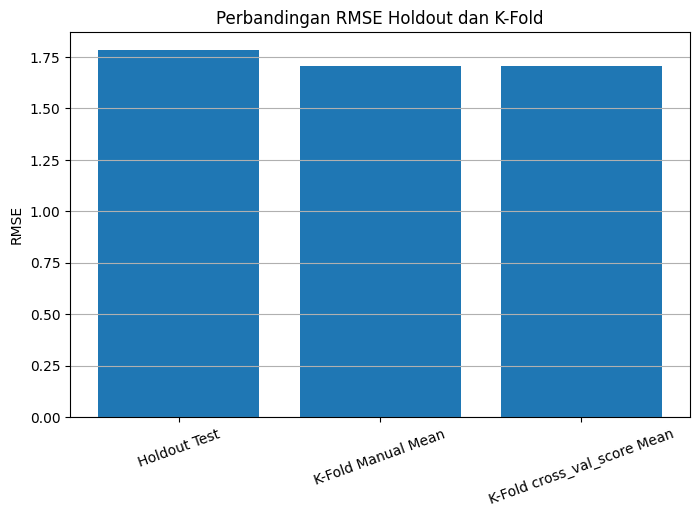

In [13]:


plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Metode"], comparison_df["RMSE"])
plt.title("Perbandingan RMSE Holdout dan K-Fold")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

In [14]:

print("=== Analisis Akhir ===")

print("RMSE Train Holdout:", round(rmse_train, 4))
print("RMSE Test Holdout :", round(rmse_test, 4))
print("RMSE K-Fold Mean  :", round(rmse_kfold_mean, 4))
print("Std K-Fold        :", round(rmse_kfold_std, 4))

print("\n2. Analisis pengaruh Holdout Validation:")

if rmse_train < rmse_test and (rmse_test - rmse_train) / rmse_train > 0.20:
    print("a. RMSE train jauh lebih kecil daripada RMSE test.")
    print("b. Model cenderung overfit karena performa pada data training jauh lebih baik daripada data testing.")
elif abs(rmse_test - rmse_train) / rmse_train <= 0.20:
    print("a. RMSE train dan RMSE test tidak berbeda jauh.")
    print("b. Model tidak menunjukkan overfitting yang kuat dan memiliki kemampuan generalisasi yang cukup baik.")
else:
    print("a. RMSE test lebih kecil daripada RMSE train.")
    print("b. Model tidak overfit. Kemungkinan data test lebih mudah diprediksi.")

print("\n3. Analisis pengaruh K-Fold Cross Validation:")

print("a. Perbandingan RMSE:")
print("   RMSE Holdout Test:", round(rmse_test, 4))
print("   RMSE K-Fold Mean :", round(rmse_kfold_mean, 4))

if abs(rmse_test - rmse_kfold_mean) <= 0.10 * rmse_kfold_mean:
    print("   RMSE Holdout dan RMSE K-Fold relatif mirip.")
else:
    print("   RMSE Holdout dan RMSE K-Fold memiliki perbedaan yang cukup terlihat.")

if rmse_kfold_std < 0.20 * rmse_kfold_mean:
    print("b. K-Fold memberikan hasil yang lebih stabil karena standar deviasi RMSE antar fold relatif kecil.")
else:
    print("b. K-Fold menunjukkan variasi performa yang cukup besar antar fold.")

print("c. Variasi kinerja model pada masing-masing fold:")
for i, rmse in enumerate(rmse_list, start=1):
    print(f"   Fold {i}: RMSE = {rmse:.4f}")

print("\nKesimpulan:")
print("Holdout Validation hanya menggunakan satu pembagian data train-test sehingga hasilnya bisa dipengaruhi oleh pembagian data tersebut.")
print("K-Fold Cross Validation lebih baik untuk evaluasi model karena seluruh data mendapat kesempatan menjadi data train dan data test.")
print("Jika nilai RMSE antar fold tidak jauh berbeda, maka model dapat dikatakan memiliki performa yang stabil.")

=== Analisis Akhir ===
RMSE Train Holdout: 1.6447
RMSE Test Holdout : 1.7816
RMSE K-Fold Mean  : 1.7057
Std K-Fold        : 0.2636

2. Analisis pengaruh Holdout Validation:
a. RMSE train dan RMSE test tidak berbeda jauh.
b. Model tidak menunjukkan overfitting yang kuat dan memiliki kemampuan generalisasi yang cukup baik.

3. Analisis pengaruh K-Fold Cross Validation:
a. Perbandingan RMSE:
   RMSE Holdout Test: 1.7816
   RMSE K-Fold Mean : 1.7057
   RMSE Holdout dan RMSE K-Fold relatif mirip.
b. K-Fold memberikan hasil yang lebih stabil karena standar deviasi RMSE antar fold relatif kecil.
c. Variasi kinerja model pada masing-masing fold:
   Fold 1: RMSE = 1.7816
   Fold 2: RMSE = 1.8149
   Fold 3: RMSE = 1.2739
   Fold 4: RMSE = 1.6822
   Fold 5: RMSE = 1.9761

Kesimpulan:
Holdout Validation hanya menggunakan satu pembagian data train-test sehingga hasilnya bisa dipengaruhi oleh pembagian data tersebut.
K-Fold Cross Validation lebih baik untuk evaluasi model karena seluruh data mendapa